# MIA Distributions Plots

In [50]:
import os
from pathlib import Path
import pandas as pd
import json

model_name = "Llama-3.2-3B-Instruct"
splits = [
    ("retain90", "forget10"),
    ("retain95", "forget05"),
    ("retain99", "forget01")
]
temperatures = [0.3, 0.5, 0.7, 1.3, 2, 3, 4]
files = [
    "saves/eval/tofu_{model_name}_{retain_split}_temp_{temperature}/TOFU_EVAL.json",
    # "saves/eval/tofu_{model_name}_pretrained_{retain_split}_temp_{temperature}/TOFU_EVAL.json"
    # "saves/eval/tofu_{model_name}_ft_{retain_split}_temp_{temperature}/TOFU_EVAL.json"
]

extracted_data = []

def get_values(data, key, split):
    try:
        return [value['score'] for value in data[key][split]['value_by_index'].values()]
    except KeyError:
        return []
    
def get_auc(data, key):
    try:
        return data[key]['auc']
    except KeyError:
        return None


for retain_split, forget_split in splits:
    for temperature in temperatures:
        for file in files:
            file = file.format(model_name=model_name, retain_split=retain_split, temperature=temperature)
            if not os.path.exists(file):
                print(f"File {file} does not exist. Skipping.")
                continue
            
            with open(file, 'r') as f:
                data = json.load(f)

            extracted_data.append({
                "model": model_name,
                "retain_split": retain_split,
                "forget_split": forget_split,
                "temperature": temperature,
                "mia_min_k_forget": get_values(data, 'mia_min_k', 'forget'),
                "mia_min_k_holdout": get_values(data, 'mia_min_k', 'holdout'),
                "mia_min_k_plus_plus_forget": get_values(data, 'mia_min_k_plus_plus', 'forget'),
                "mia_min_k_plus_plus_holdout": get_values(data, 'mia_min_k_plus_plus', 'holdout'),
                "mia_loss_forget": get_values(data, 'mia_loss', 'forget'),
                "mia_loss_holdout": get_values(data, 'mia_loss', 'holdout'),
                "mia_min_k_auc": get_auc(data, 'mia_min_k'),
                "mia_min_k_plus_plus_auc": get_auc(data, 'mia_min_k_plus_plus'),
                "mia_loss_auc": get_auc(data, 'mia_loss'),
            })

df = pd.DataFrame(extracted_data)
display(df)



File saves/eval/tofu_Llama-3.2-3B-Instruct_retain95_temp_0.3/TOFU_EVAL.json does not exist. Skipping.
File saves/eval/tofu_Llama-3.2-3B-Instruct_retain95_temp_0.5/TOFU_EVAL.json does not exist. Skipping.
File saves/eval/tofu_Llama-3.2-3B-Instruct_retain95_temp_0.7/TOFU_EVAL.json does not exist. Skipping.
File saves/eval/tofu_Llama-3.2-3B-Instruct_retain95_temp_1.3/TOFU_EVAL.json does not exist. Skipping.
File saves/eval/tofu_Llama-3.2-3B-Instruct_retain95_temp_2/TOFU_EVAL.json does not exist. Skipping.
File saves/eval/tofu_Llama-3.2-3B-Instruct_retain95_temp_3/TOFU_EVAL.json does not exist. Skipping.
File saves/eval/tofu_Llama-3.2-3B-Instruct_retain95_temp_4/TOFU_EVAL.json does not exist. Skipping.


,model,retain_split,forget_split,temperature,mia_min_k_forget,mia_min_k_holdout,mia_min_k_plus_plus_forget,mia_min_k_plus_plus_holdout,mia_loss_forget,mia_loss_holdout,mia_min_k_auc,mia_min_k_plus_plus_auc,mia_loss_auc
0,Llama-3.2-3B-Instruct,retain90,forget10,0.3,"[17.806180953979492, 9.002517700195312, 5.3738...","[5.354344844818115, 21.193103790283203, 16.724...","[2.987771511077881, 2.612684965133667, 0.41193...","[0.8497270345687866, 29.019380569458008, 3.262...","[6.520103931427002, 3.2151849269866943, 1.9192...","[1.862382173538208, 7.417585849761963, 6.19652...",0.402506,0.480112,0.411681
1,Llama-3.2-3B-Instruct,retain90,forget10,0.5,"[11.019876480102539, 5.422622203826904, 3.3246...","[3.6184420585632324, 12.89136028289795, 10.275...","[2.987771511077881, 2.612684965133667, 0.41193...","[0.8497270345687866, 29.019380569458008, 3.262...","[4.123154640197754, 1.9366604089736938, 1.1873...","[1.258679747581482, 4.511988639831543, 3.81477...",0.401800,0.480112,0.410831
2,Llama-3.2-3B-Instruct,retain90,forget10,0.7,"[8.34908676147461, 3.918043613433838, 2.503558...","[2.9353294372558594, 9.376693725585938, 7.6076...","[2.987771511077881, 2.612684965133667, 0.41193...","[0.8497270345687866, 29.019380569458008, 3.262...","[3.176949977874756, 1.399457335472107, 0.89439...","[1.0216646194458008, 3.2820324897766113, 2.837...",0.400344,0.480112,0.409069
3,Llama-3.2-3B-Instruct,retain90,forget10,1.3,"[5.90903377532959, 2.4532763957977295, 1.95060...","[2.3243932723999023, 5.635904788970947, 5.1024...","[2.987771511077881, 2.612684965133667, 0.41193...","[0.8497270345687866, 29.019380569458008, 3.262...","[2.4883527755737305, 0.8924034237861633, 0.709...","[0.8429519534111023, 1.9887765645980835, 2.018...",0.391525,0.480112,0.398456
4,Llama-3.2-3B-Instruct,retain90,forget10,2.0,"[6.634360313415527, 3.9193930625915527, 3.5340...","[3.4882259368896484, 5.570387363433838, 5.9090...","[2.987771511077881, 2.612684965133667, 0.41193...","[0.8497270345687866, 29.019380569458008, 3.262...","[3.702786922454834, 1.9192363023757935, 1.7208...","[1.8772423267364502, 2.4874789714813232, 3.104...",0.378625,0.480112,0.372356
5,Llama-3.2-3B-Instruct,retain90,forget10,3.0,"[8.110652923583984, 6.324145793914795, 6.01830...","[5.884104251861572, 7.219879150390625, 7.60394...","[2.987771511077881, 2.612684965133667, 0.41193...","[0.8497270345687866, 29.019380569458008, 3.262...","[6.071250915527344, 4.596726417541504, 4.45125...","[4.625547885894775, 4.953692436218262, 5.50770...",0.375381,0.480112,0.364825
6,Llama-3.2-3B-Instruct,retain90,forget10,4.0,"[8.973676681518555, 7.640839576721191, 7.40632...","[7.3047051429748535, 8.299161911010742, 8.5901...","[2.987771511077881, 2.612684965133667, 0.41193...","[0.8497270345687866, 29.019380569458008, 3.262...","[7.44339656829834, 6.327996253967285, 6.214279...","[6.34930419921875, 6.590827941894531, 7.010823...",0.375281,0.480112,0.364188
7,Llama-3.2-3B-Instruct,retain99,forget01,0.3,"[11.753838539123535, 7.444754123687744, 0.0658...","[4.474316596984863, 21.932828903198242, 15.751...","[3.776287078857422, 1.0730661153793335, -0.011...","[0.5319938659667969, 37.10981369018555, 7.5301...","[4.570940017700195, 2.6588406562805176, 0.0219...","[1.5562840700149536, 7.676489353179932, 5.8343...",0.537500,0.548750,0.538750
8,Llama-3.2-3B-Instruct,retain99,forget01,0.5,"[7.132391452789307, 4.492929458618164, 0.11574...","[3.114993095397949, 13.243429183959961, 9.7617...","[3.776287078857422, 1.0730661153793335, -0.011...","[0.5319938659667969, 37.10981369018555, 7.5301...","[2.773846387863159, 1.604617953300476, 0.03858...","[1.0835131406784058, 4.635205268859863, 3.6201...",0.538125,0.548750,0.540625
9,Llama-3.2-3B-Instruct,retain99,forget01,0.7,"[5.196148872375488, 3.25203275680542, 0.173180...","[2.5784640312194824, 9.567924499511719, 7.2906...","[3.776287078857422, 1.0730661153793335, -0.011...","[0.5319938659667969, 37.10981369018555, 7.5301...","[2.021707057952881, 1.1614539623260498, 0.0577...","[0.897401

## MIA Min-K%

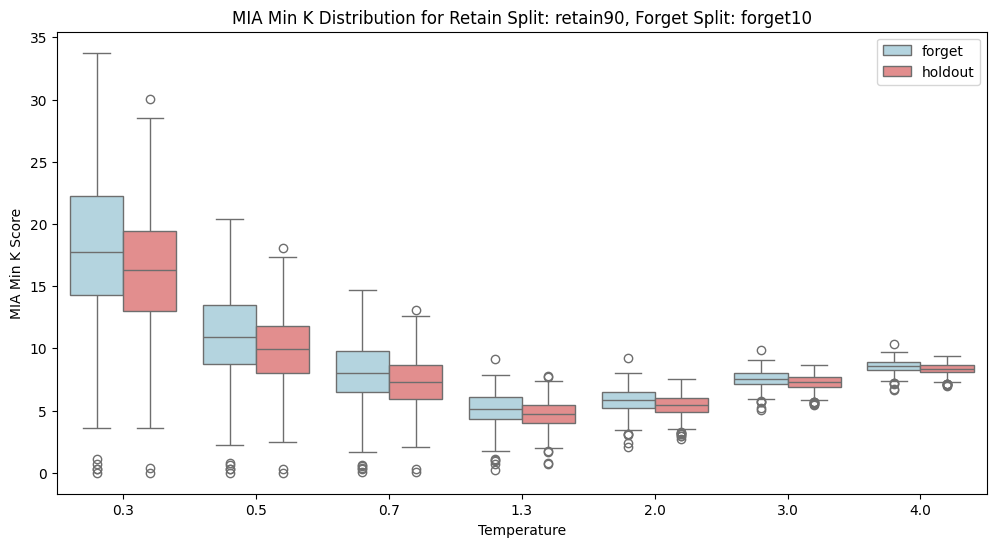

No data for retain_split=retain95 and forget_split=forget05. Skipping plot.


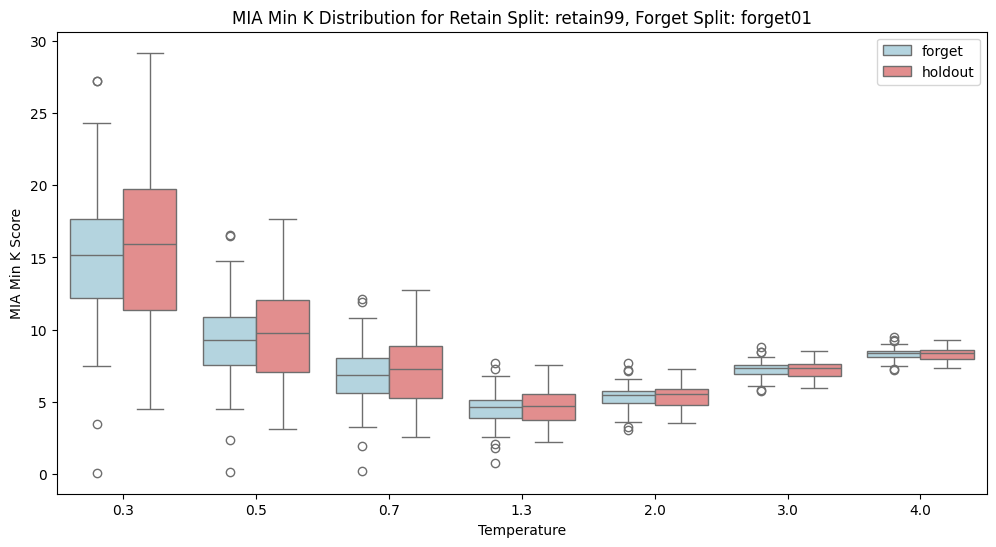

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

for retain_split, forget_split in splits:
    subset = df[(df['retain_split'] == retain_split) & (df['forget_split'] == forget_split)]
    if subset.empty:
        print(f"No data for retain_split={retain_split} and forget_split={forget_split}. Skipping plot.")
        continue

    forget_df = subset[['temperature', 'mia_min_k_forget']].explode('mia_min_k_forget').rename(columns={'mia_min_k_forget': 'score'})
    forget_df['split'] = 'forget'
    holdout_df = subset[['temperature', 'mia_min_k_holdout']].explode('mia_min_k_holdout').rename(columns={'mia_min_k_holdout': 'score'})
    holdout_df['split'] = 'holdout'
    long_df = pd.concat([forget_df, holdout_df], ignore_index=True)
    long_df['score'] = long_df['score'].astype(float)

    plt.figure(figsize=(12, 6))
    sns.boxplot(x='temperature', y='score', hue='split', data=long_df, palette={'forget': 'lightblue', 'holdout': 'lightcoral'})
    plt.title(f'MIA Min K Distribution for Retain Split: {retain_split}, Forget Split: {forget_split}')
    plt.xlabel('Temperature')
    plt.ylabel('MIA Min K Score')
    plt.legend()
    plt.show()


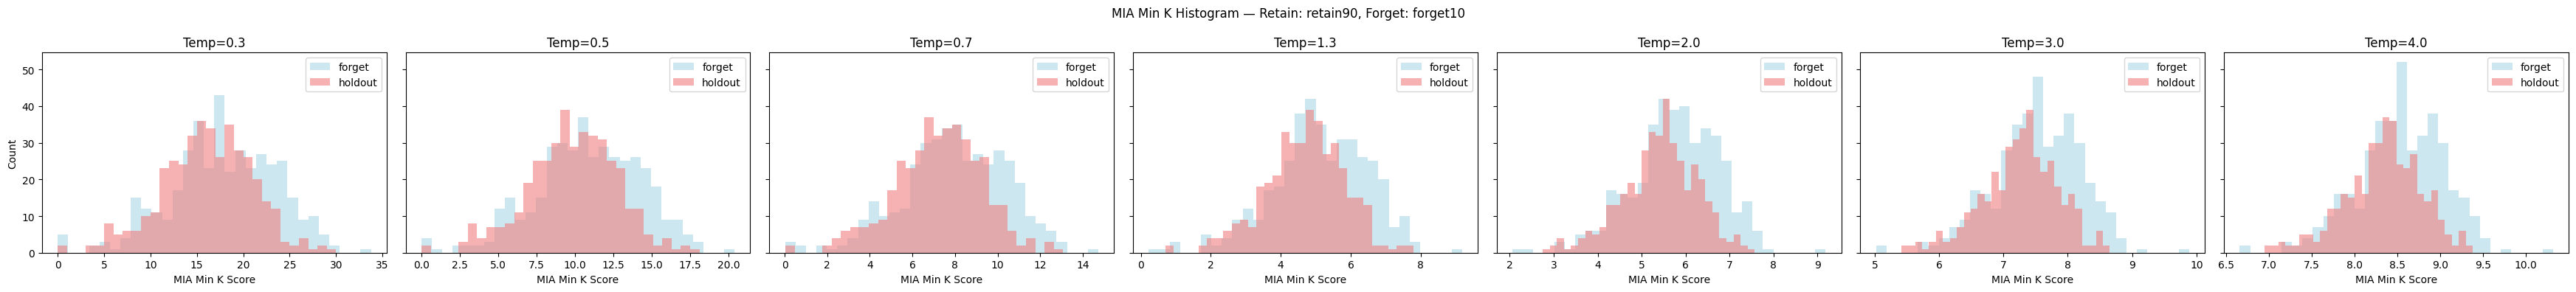

No data for retain_split=retain95 and forget_split=forget05. Skipping plot.


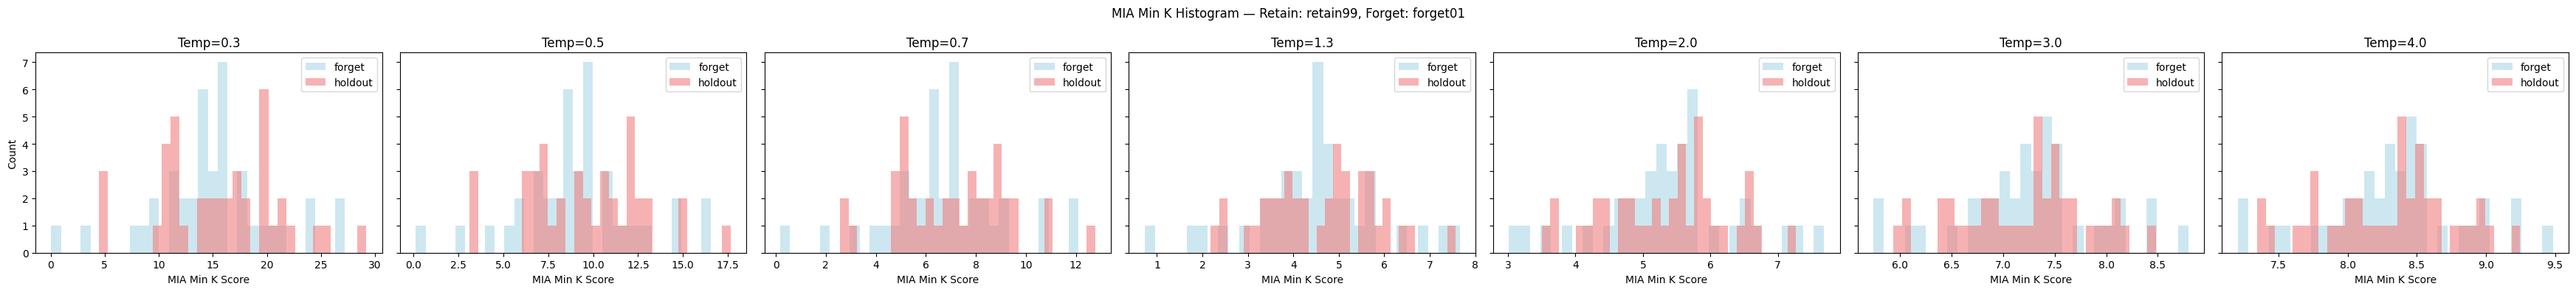

In [37]:
for retain_split, forget_split in splits:
    subset = df[(df['retain_split'] == retain_split) & (df['forget_split'] == forget_split)]
    if subset.empty:
        print(f"No data for retain_split={retain_split} and forget_split={forget_split}. Skipping plot.")
        continue

    forget_df = subset[['temperature', 'mia_min_k_forget']].explode('mia_min_k_forget').rename(columns={'mia_min_k_forget': 'score'})
    forget_df['split'] = 'forget'
    holdout_df = subset[['temperature', 'mia_min_k_holdout']].explode('mia_min_k_holdout').rename(columns={'mia_min_k_holdout': 'score'})
    holdout_df['split'] = 'holdout'
    long_df = pd.concat([forget_df, holdout_df], ignore_index=True)
    long_df['score'] = long_df['score'].astype(float)

    temps = sorted(long_df['temperature'].unique())
    fig, axes = plt.subplots(1, len(temps), figsize=(5 * len(temps), 4), sharey=True)
    if len(temps) == 1:
        axes = [axes]

    for ax, temp in zip(axes, temps):
        temp_df = long_df[long_df['temperature'] == temp]
        for split, color in [('forget', 'lightblue'), ('holdout', 'lightcoral')]:
            scores = temp_df[temp_df['split'] == split]['score']
            ax.hist(scores, bins=30, alpha=0.6, color=color, label=split)
        ax.set_title(f'Temp={temp}')
        ax.set_xlabel('MIA Min K Score')
        ax.legend()

    axes[0].set_ylabel('Count')
    fig.suptitle(f'MIA Min K Histogram — Retain: {retain_split}, Forget: {forget_split}')
    plt.tight_layout()
    plt.show()


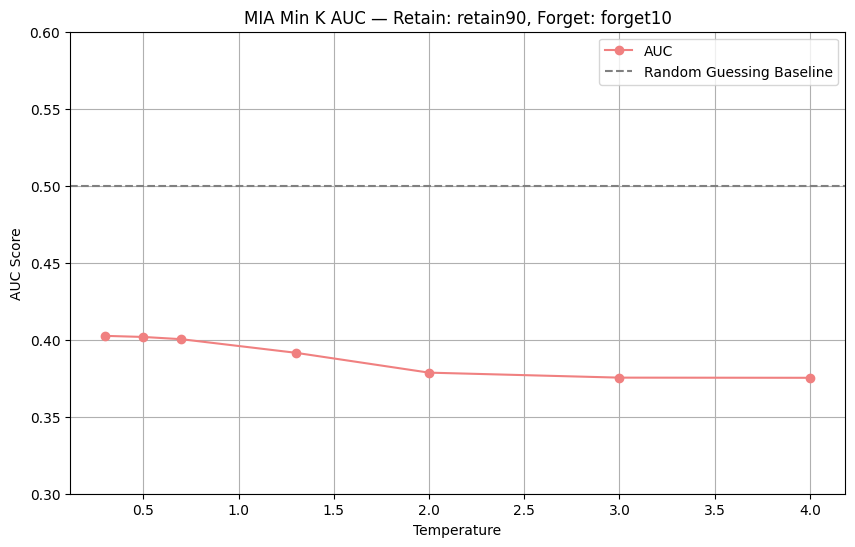

No data for retain_split=retain95 and forget_split=forget05. Skipping plot.


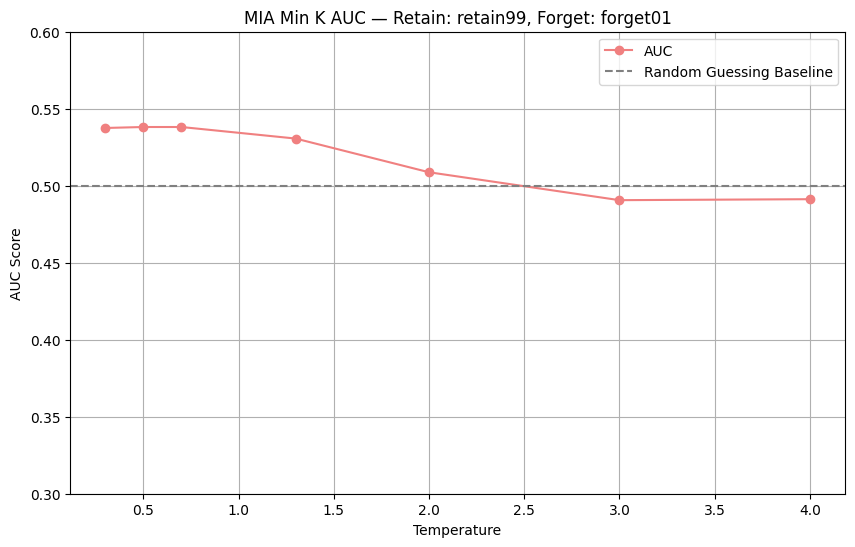

In [57]:
# Plot the mia_min_k_auc_forget and mia_min_k_auc_holdout values for each temperature and split as a line plot
for retain_split, forget_split in splits:
    subset = df[(df['retain_split'] == retain_split) & (df['forget_split'] == forget_split)]
    if subset.empty:
        print(f"No data for retain_split={retain_split} and forget_split={forget_split}. Skipping plot.")
        continue

    plt.figure(figsize=(10, 6))
    plt.plot(subset['temperature'], subset['mia_min_k_auc'], marker='o', color='lightcoral', label='AUC')
    plt.title(f'MIA Min K AUC — Retain: {retain_split}, Forget: {forget_split}')
    # Make a dotted line at y=0.5 to indicate random guessing baseline
    plt.axhline(0.5, color='gray', linestyle='--', label='Random Guessing Baseline')
    plt.legend()
    plt.ylim(0.3, 0.6)
    plt.xlabel('Temperature')
    plt.ylabel('AUC Score')
    plt.grid()
    plt.show()
    

## MIA MIN-K%++

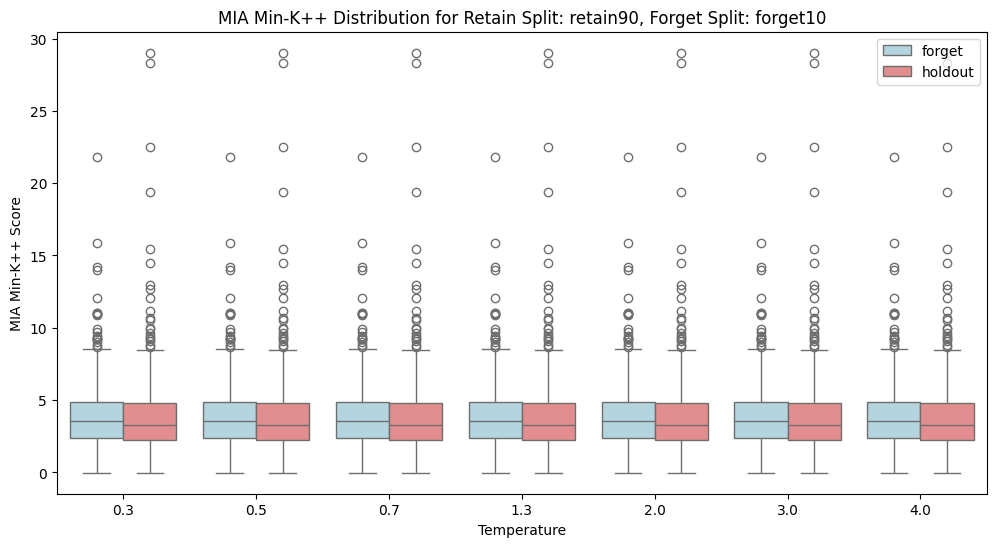

No data for retain_split=retain95 and forget_split=forget05. Skipping plot.


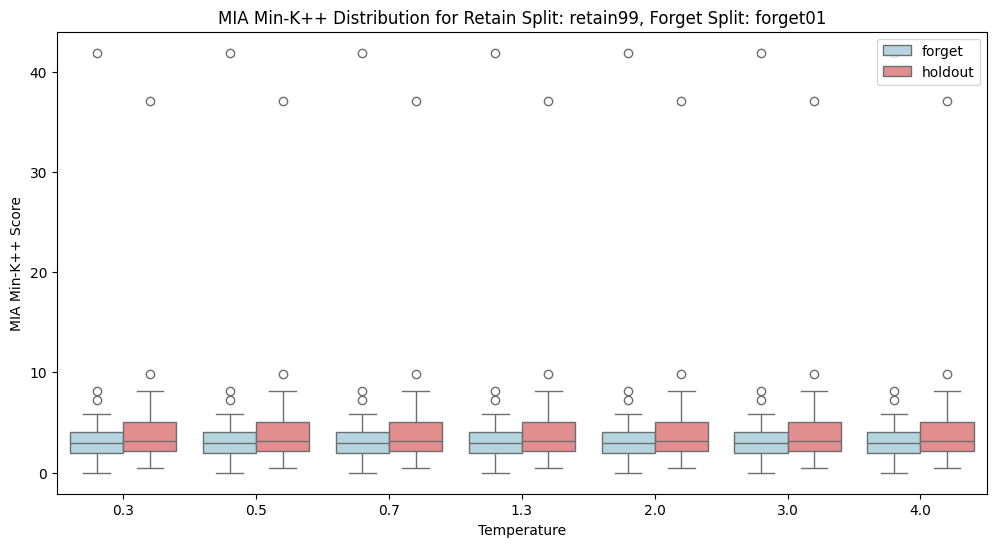

In [38]:
for retain_split, forget_split in splits:
    subset = df[(df['retain_split'] == retain_split) & (df['forget_split'] == forget_split)]
    if subset.empty:
        print(f"No data for retain_split={retain_split} and forget_split={forget_split}. Skipping plot.")
        continue

    forget_df = subset[['temperature', 'mia_min_k_plus_plus_forget']].explode('mia_min_k_plus_plus_forget').rename(columns={'mia_min_k_plus_plus_forget': 'score'})
    forget_df['split'] = 'forget'
    holdout_df = subset[['temperature', 'mia_min_k_plus_plus_holdout']].explode('mia_min_k_plus_plus_holdout').rename(columns={'mia_min_k_plus_plus_holdout': 'score'})
    holdout_df['split'] = 'holdout'
    long_df = pd.concat([forget_df, holdout_df], ignore_index=True)
    long_df['score'] = pd.to_numeric(long_df['score'], errors='coerce')
    long_df = long_df.dropna(subset=['score'])

    plt.figure(figsize=(12, 6))
    sns.boxplot(x='temperature', y='score', hue='split', data=long_df, palette={'forget': 'lightblue', 'holdout': 'lightcoral'})
    plt.title(f'MIA Min-K++ Distribution for Retain Split: {retain_split}, Forget Split: {forget_split}')
    plt.xlabel('Temperature')
    plt.ylabel('MIA Min-K++ Score')
    plt.legend()
    plt.show()


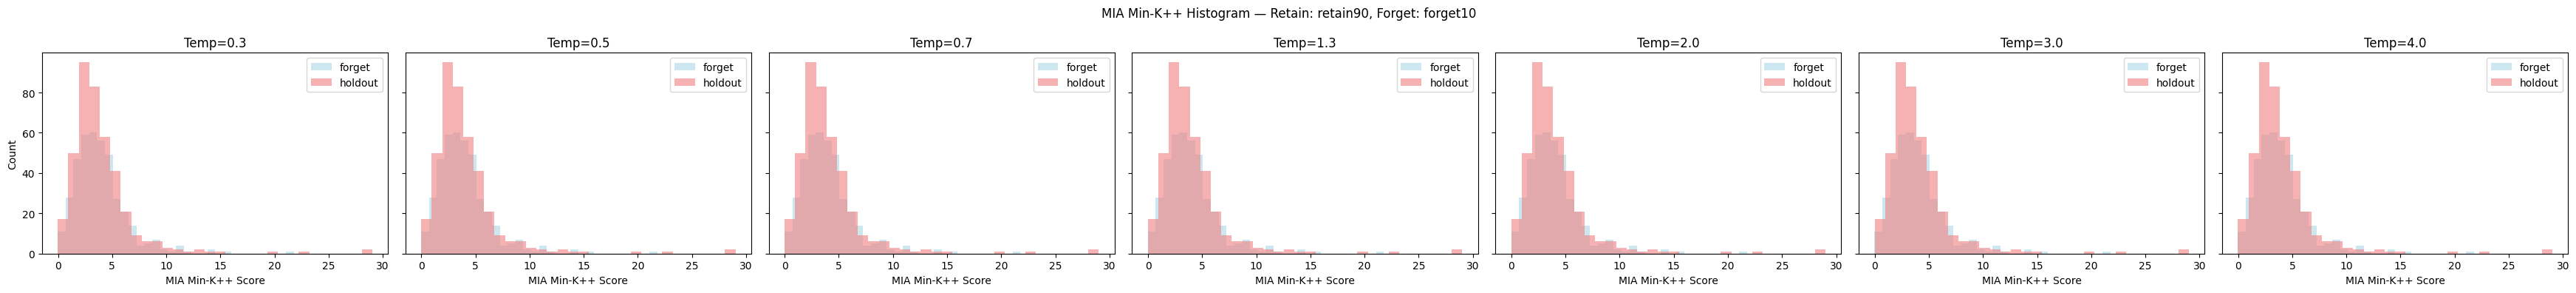

No data for retain_split=retain95 and forget_split=forget05. Skipping plot.


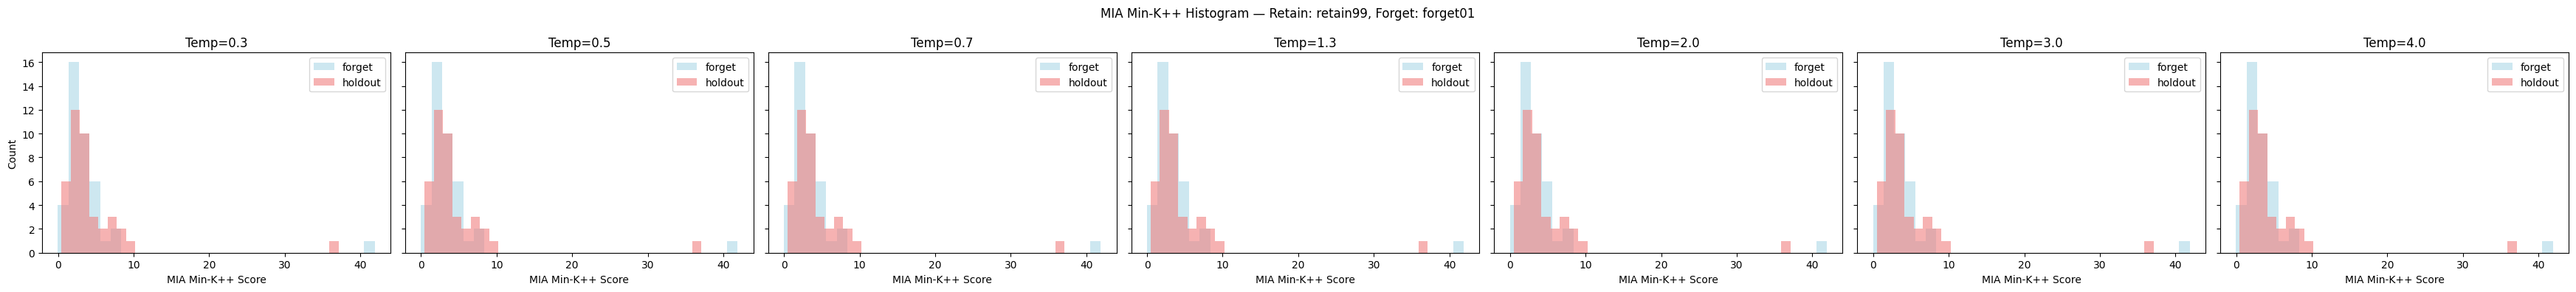

In [39]:
for retain_split, forget_split in splits:
    subset = df[(df['retain_split'] == retain_split) & (df['forget_split'] == forget_split)]
    if subset.empty:
        print(f"No data for retain_split={retain_split} and forget_split={forget_split}. Skipping plot.")
        continue

    forget_df = subset[['temperature', 'mia_min_k_plus_plus_forget']].explode('mia_min_k_plus_plus_forget').rename(columns={'mia_min_k_plus_plus_forget': 'score'})
    forget_df['split'] = 'forget'
    holdout_df = subset[['temperature', 'mia_min_k_plus_plus_holdout']].explode('mia_min_k_plus_plus_holdout').rename(columns={'mia_min_k_plus_plus_holdout': 'score'})
    holdout_df['split'] = 'holdout'
    long_df = pd.concat([forget_df, holdout_df], ignore_index=True)
    long_df['score'] = pd.to_numeric(long_df['score'], errors='coerce')
    long_df = long_df.dropna(subset=['score'])

    temps = sorted(long_df['temperature'].unique())
    fig, axes = plt.subplots(1, len(temps), figsize=(5 * len(temps), 4), sharey=True)
    if len(temps) == 1:
        axes = [axes]

    for ax, temp in zip(axes, temps):
        temp_df = long_df[long_df['temperature'] == temp]
        for split, color in [('forget', 'lightblue'), ('holdout', 'lightcoral')]:
            scores = temp_df[temp_df['split'] == split]['score']
            ax.hist(scores, bins=30, alpha=0.6, color=color, label=split)
        ax.set_title(f'Temp={temp}')
        ax.set_xlabel('MIA Min-K++ Score')
        ax.legend()

    axes[0].set_ylabel('Count')
    fig.suptitle(f'MIA Min-K++ Histogram — Retain: {retain_split}, Forget: {forget_split}')
    plt.tight_layout()
    plt.show()


## MIA Loss

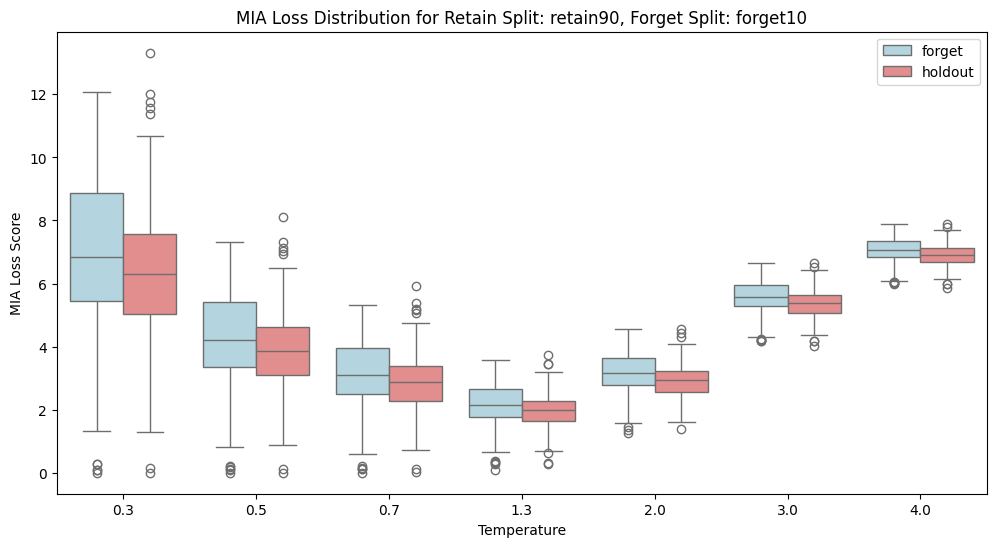

No data for retain_split=retain95 and forget_split=forget05. Skipping plot.


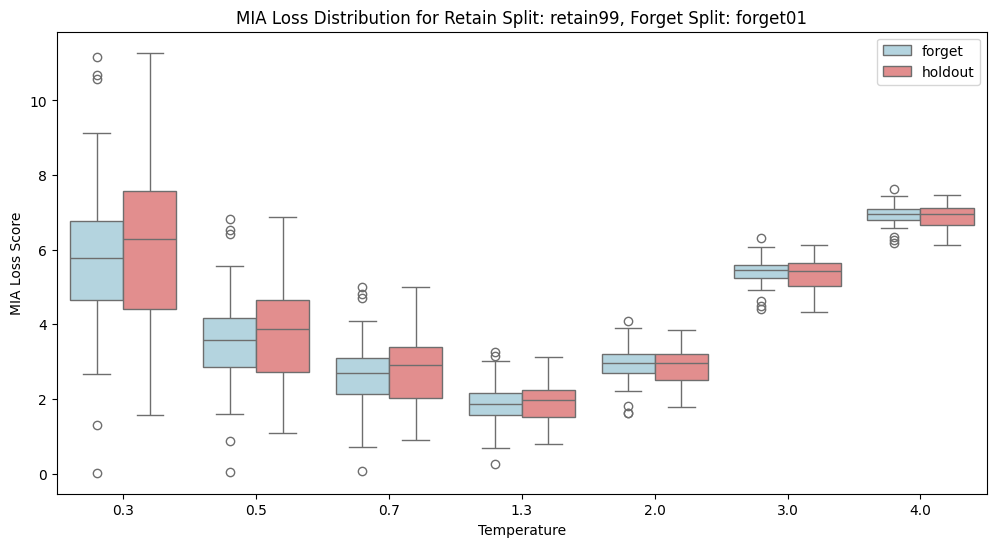

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt

for retain_split, forget_split in splits:
    subset = df[(df['retain_split'] == retain_split) & (df['forget_split'] == forget_split)]
    if subset.empty:
        print(f"No data for retain_split={retain_split} and forget_split={forget_split}. Skipping plot.")
        continue

    forget_df = subset[['temperature', 'mia_loss_forget']].explode('mia_loss_forget').rename(columns={'mia_loss_forget': 'score'})
    forget_df['split'] = 'forget'
    holdout_df = subset[['temperature', 'mia_loss_holdout']].explode('mia_loss_holdout').rename(columns={'mia_loss_holdout': 'score'})
    holdout_df['split'] = 'holdout'
    long_df = pd.concat([forget_df, holdout_df], ignore_index=True)
    long_df['score'] = long_df['score'].astype(float)

    plt.figure(figsize=(12, 6))
    sns.boxplot(x='temperature', y='score', hue='split', data=long_df, palette={'forget': 'lightblue', 'holdout': 'lightcoral'})
    plt.title(f'MIA Loss Distribution for Retain Split: {retain_split}, Forget Split: {forget_split}')
    plt.xlabel('Temperature')
    plt.ylabel('MIA Loss Score')
    plt.legend()
    plt.show()


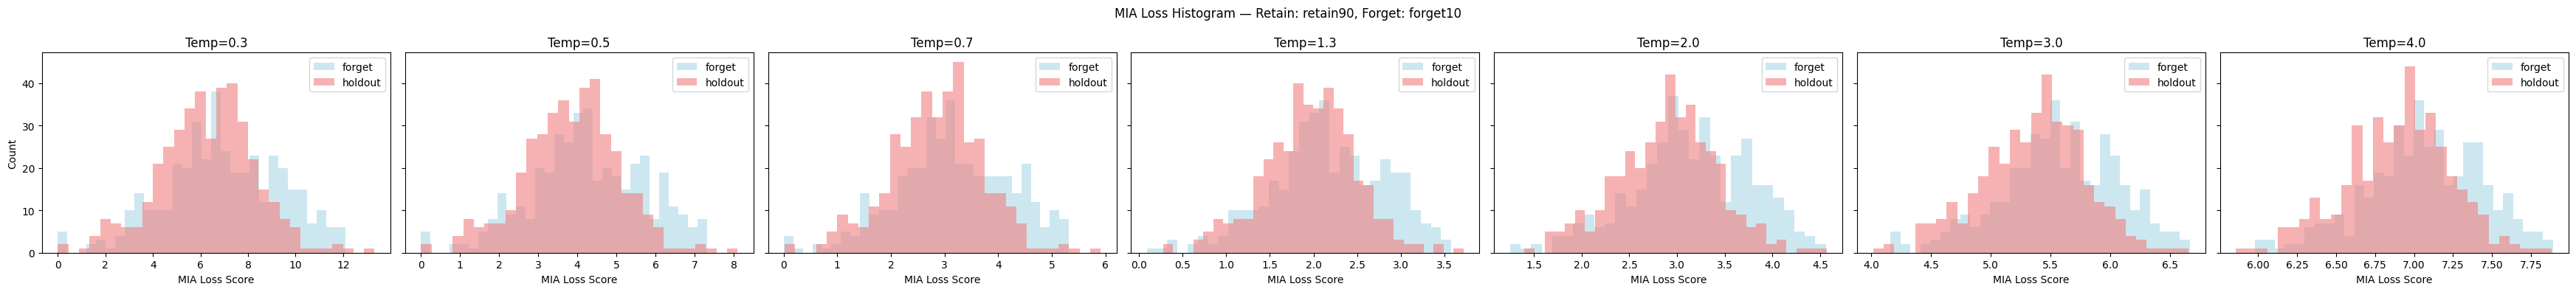

No data for retain_split=retain95 and forget_split=forget05. Skipping plot.


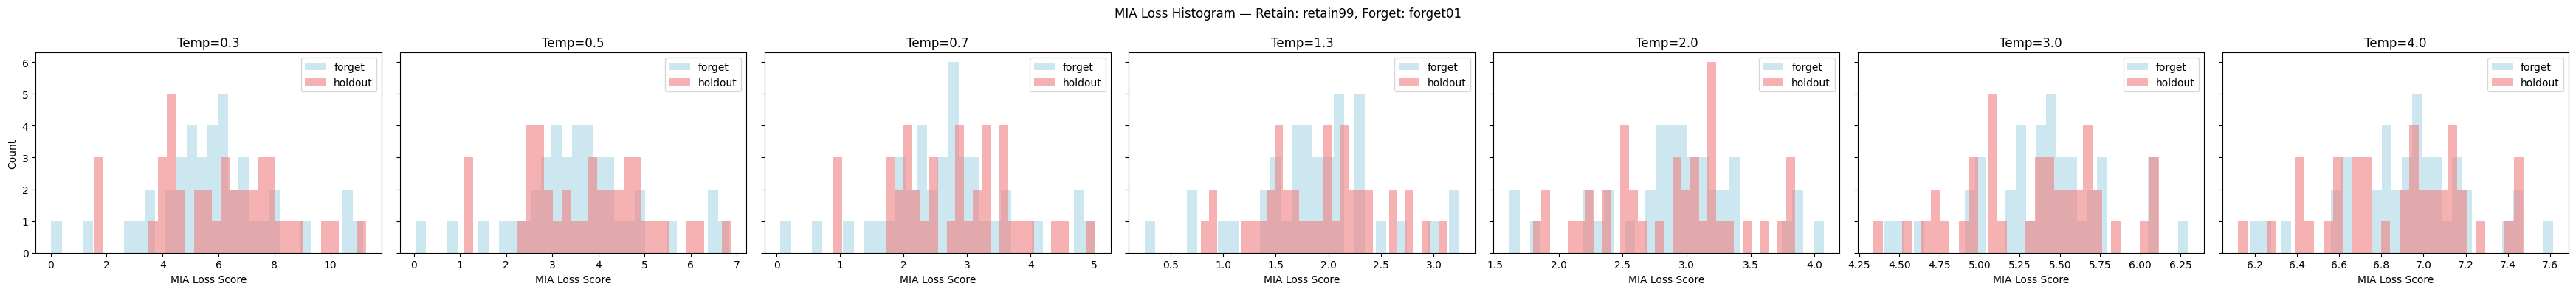

In [41]:
for retain_split, forget_split in splits:
    subset = df[(df['retain_split'] == retain_split) & (df['forget_split'] == forget_split)]
    if subset.empty:
        print(f"No data for retain_split={retain_split} and forget_split={forget_split}. Skipping plot.")
        continue

    forget_df = subset[['temperature', 'mia_loss_forget']].explode('mia_loss_forget').rename(columns={'mia_loss_forget': 'score'})
    forget_df['split'] = 'forget'
    holdout_df = subset[['temperature', 'mia_loss_holdout']].explode('mia_loss_holdout').rename(columns={'mia_loss_holdout': 'score'})
    holdout_df['split'] = 'holdout'
    long_df = pd.concat([forget_df, holdout_df], ignore_index=True)
    long_df['score'] = pd.to_numeric(long_df['score'], errors='coerce')
    long_df = long_df.dropna(subset=['score'])

    temps = sorted(long_df['temperature'].unique())
    fig, axes = plt.subplots(1, len(temps), figsize=(5 * len(temps), 4), sharey=True)
    if len(temps) == 1:
        axes = [axes]

    for ax, temp in zip(axes, temps):
        temp_df = long_df[long_df['temperature'] == temp]
        for split, color in [('forget', 'lightblue'), ('holdout', 'lightcoral')]:
            scores = temp_df[temp_df['split'] == split]['score']
            ax.hist(scores, bins=30, alpha=0.6, color=color, label=split)
        ax.set_title(f'Temp={temp}')
        ax.set_xlabel('MIA Loss Score')
        ax.legend()

    axes[0].set_ylabel('Count')
    fig.suptitle(f'MIA Loss Histogram — Retain: {retain_split}, Forget: {forget_split}')
    plt.tight_layout()
    plt.show()


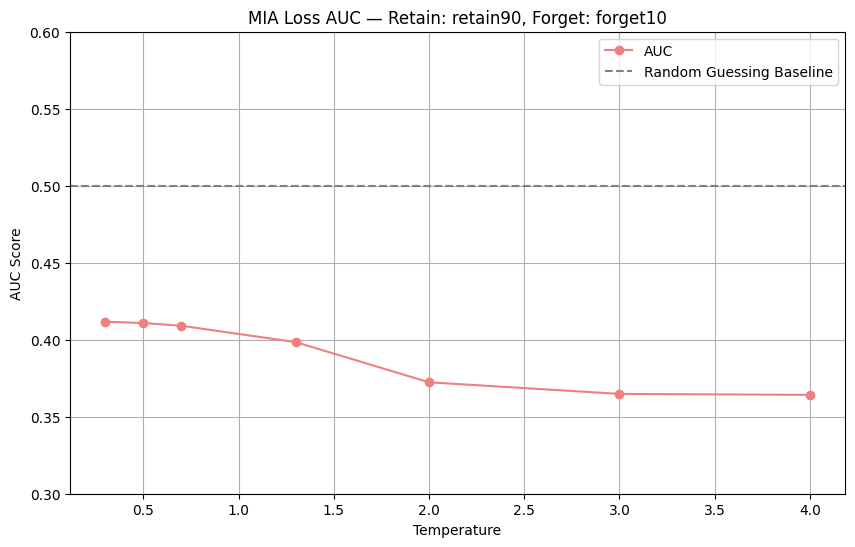

No data for retain_split=retain95 and forget_split=forget05. Skipping plot.


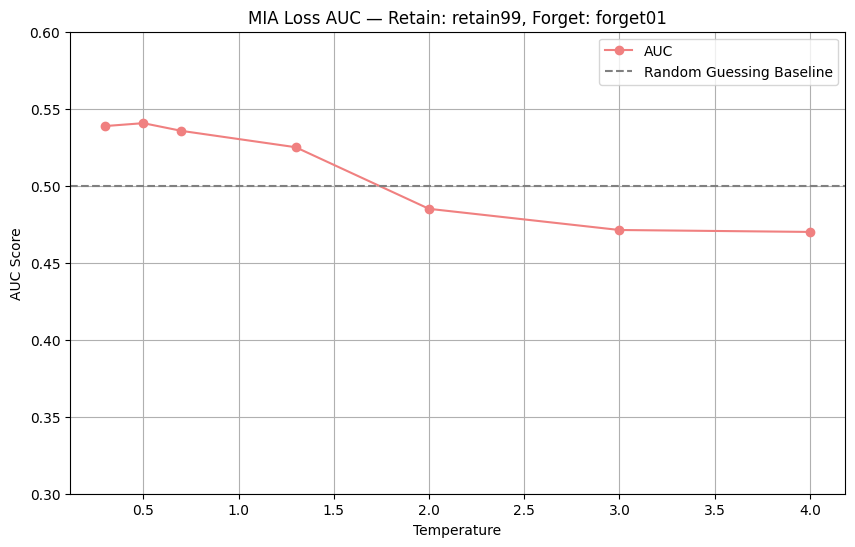

In [56]:
# Plot the mia_loss_auc values for each temperature and split as a line plot
for retain_split, forget_split in splits:
    subset = df[(df['retain_split'] == retain_split) & (df['forget_split'] == forget_split)]
    if subset.empty:
        print(f"No data for retain_split={retain_split} and forget_split={forget_split}. Skipping plot.")
        continue

    plt.figure(figsize=(10, 6))
    plt.plot(subset['temperature'], subset['mia_loss_auc'], marker='o', color='lightcoral', label='AUC')
    plt.title(f'MIA Loss AUC — Retain: {retain_split}, Forget: {forget_split}')
    # Make a dotted line at y=0.5 to indicate random guessing baseline
    plt.axhline(0.5, color='gray', linestyle='--', label='Random Guessing Baseline')
    plt.legend()
    plt.ylim(0.3, 0.6)
    plt.xlabel('Temperature')
    plt.ylabel('AUC Score')
    plt.grid()
    plt.show()